In [1]:
"""
shortcut_stratified_analysis.py
================================
Analyses C0 and C2 performance stratified by Support Device status.

Requires:
    - c2_data.csv : C2 features including delta cols
    - train.csv: original CheXpert train CSV with 'Support Devices' column

Outputs:
    - Printed tables for C0 accuracy, C2 detection rate, ΔA magnitude per stratum
"""

"\nshortcut_stratified_analysis.py\n================================\nAnalyses C0 and C2 performance stratified by Support Device status.\n\nRequires:\n    - c2_data.csv : C2 features including delta cols\n    - train.csv: original CheXpert train CSV with 'Support Devices' column\n\nOutputs:\n    - Printed tables for C0 accuracy, C2 detection rate, ΔA magnitude per stratum\n"

In [54]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
# Plot roc curves by stratum
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ── CONFIG ────────────────────────────────────────────────────────────────────
DISEASE   = 'effusion'
CF_COUNT  = 1
BASE_DIR  = '/zhome/d0/a/221493/thesis/'

C2_PATH   = f'{BASE_DIR}results/C2_custom/c2_data.csv'
CHEX_PATH = f'{BASE_DIR}data/CheXpert-v1.0-small/train.csv'  # has 'Support Devices' col



In [5]:
# ── LOAD ──────────────────────────────────────────────────────────────────────
c2_df   = pd.read_csv(C2_PATH)
chex_df = pd.read_csv(CHEX_PATH)[['Path', 'Support Devices']]


In [6]:
c2_df

,path,prob,true,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,Aorta_original_firstorder_Mean,Aorta_original_firstorder_Median,Aorta_original_firstorder_Minimum,Aorta_original_firstorder_Range,Aorta_original_firstorder_RobustMeanAbsoluteDeviation,Aorta_original_firstorder_RootMeanSquared,Aorta_original_firstorder_Skewness,Aorta_original_firstorder_TotalEnergy,Aorta_original_firstorder_Uniformity,Aorta_original_firstorder_Variance
0,CheXpert-v1.0-small/train/patient00005/study1/...,0.041813,0.0,-0.001189,-0.001186,0.002146,0.004988,-0.102878,0.176344,-0.001303,...,567.888093,646.393494,-65.630211,979.157249,150.293437,617.916926,-0.809970,1.172191e+08,0.039672,59324.441149
1,CheXpert-v1.0-small/train/patient00006/study1/...,0.215646,0.0,-0.001187,-0.003954,0.007097,0.003398,-0.039020,0.381182,-0.001332,...,34.056039,48.996605,-689.254150,1126.734589,96.362326,185.642746,-0.652183,3.511803e+07,0.041965,33303.415247
2,CheXpert-v1.0-small/train/patient00008/study1/...,0.989891,1.0,-0.001258,-0.002981,0.004603,0.001782,0.038358,0.399419,-0.001282,...,286.560282,357.584167,-409.044739,1017.673828,95.900233,347.399748,-1.382682,1.007733e+08,0.057587,38569.789807
3,CheXpert-v1.0-small/train/patient00008/study2/...,0.803473,1.0,-0.001191,-0.002815,0.002819,0.001348,0.057667,0.703849,-0.001344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CheXpert-v1.0-small/train/patient00010/study1/...,0.022443,0.0,-0.001185,-0.000544,0.002301,0.005169,-0.117937,-0.033050,-0.001290,...,213.656361,221.533264,-713.253662,1709.125610,216.630374,441.249354,-0.057772,1.177941e+08,0.020209,149051.951785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45150,CheXpert-v1.0-small/train/patient47343/study4/...,0.254282,0.0,-0.001193,-0.000746,0.004451,0.002484,0.093905,0.294997,-0.001299,...,-78.911822,7.484866,-748.935486,996.037933,140.442993,239.189061,-0.828364,3.015041e+07,0.041562,50984.331080
45151,CheXpert-v1.0-small/train/patient47343/study5/...,0.190549,0.0,-0.001195,-0.000948,0.003515,0.003376,0.002050,0.100450,-0.001304,...,166.455575,249.356003,-590.689453,1055.035339,102.029540,280.504147,-1.452701,4.004943e+07,0.056241,50975.118192
45152,CheXpert-v1.0-small/train/patient47344/study4/...,0.999278,1.0,-0.001212,-0.003042,0.003746,-0.000372,0.070899,0.830360,-0.001302,...,437.703904,506.113647,-268.893646,969.057587,82.569345,474.512460,-1.599859,1.508586e+08,0.076489,33577.367070
45153,CheXpert-v1.0-small/train/patient47344/study3/...,0.997430,1.0,-0.001218,-0.002592,0.004545,0.002813,-0.001787,0.486378,-0.001291,...,369.637714,417.336212,-455.067108,1149.506439,98.581153,413.320162,-1.236381,1.482835e+08,0.050213,34201.516570


In [7]:
chex_df

,Path,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,NaN
...,...,...
223409,CheXpert-v1.0-small/train/patient64537/study2/...,NaN
223410,CheXpert-v1.0-small/train/patient64537/study1/...,NaN
223411,CheXpert-v1.0-small/train/patient64538/study1/...,NaN
223412,CheXpert-v1.0-small/train/patient64539/study1/...,0.0


In [8]:
# ── MERGE SUPPORT DEVICE LABELS ───────────────────────────────────────────────
# CheXpert paths may have a different prefix, adjust if needed
c2_df = c2_df.merge(chex_df, left_on='path', right_on='Path', how='left')

# Collapse into 3 strata: Present, Absent, Unknown
def label_stratum(val):
    if val == 1.0:
        return 'Present'
    elif val == 0.0:
        return 'Absent'
    else:  # NaN, -1.0
        return 'Unknown'

c2_df['stratum'] = c2_df['Support Devices'].apply(label_stratum)


In [9]:
c2_df.head()

,path,prob,true,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,Aorta_original_firstorder_Range,Aorta_original_firstorder_RobustMeanAbsoluteDeviation,Aorta_original_firstorder_RootMeanSquared,Aorta_original_firstorder_Skewness,Aorta_original_firstorder_TotalEnergy,Aorta_original_firstorder_Uniformity,Aorta_original_firstorder_Variance,Path,Support Devices,stratum
0,CheXpert-v1.0-small/train/patient00005/study1/...,0.041813,0.0,-0.001189,-0.001186,0.002146,0.004988,-0.102878,0.176344,-0.001303,...,979.157249,150.293437,617.916926,-0.809970,1.172191e+08,0.039672,59324.441149,CheXpert-v1.0-small/train/patient00005/study1/...,1.0,Present
1,CheXpert-v1.0-small/train/patient00006/study1/...,0.215646,0.0,-0.001187,-0.003954,0.007097,0.003398,-0.039020,0.381182,-0.001332,...,1126.734589,96.362326,185.642746,-0.652183,3.511803e+07,0.041965,33303.415247,CheXpert-v1.0-small/train/patient00006/study1/...,NaN,Unknown
2,CheXpert-v1.0-small/train/patient00008/study1/...,0.989891,1.0,-0.001258,-0.002981,0.004603,0.001782,0.038358,0.399419,-0.001282,...,1017.673828,95.900233,347.399748,-1.382682,1.007733e+08,0.057587,38569.789807,CheXpert-v1.0-small/train/patient00008/study1/...,1.0,Present
3,CheXpert-v1.0-small/train/patient00008/study2/...,0.803473,1.0,-0.001191,-0.002815,0.002819,0.001348,0.057667,0.703849,-0.001344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CheXpert-v1.0-small/train/patient00008/study2/...,1.0,Present
4,CheXpert-v1.0-small/train/patient00010/study1/...,0.022443,0.0,-0.001185,-0.000544,0.002301,0.005169,-0.117937,-0.033050,-0.001290,...,1709.125610,216.630374,441.249354,-0.057772,1.177941e+08,0.020209,149051.951785,CheXpert-v1.0-small/train/patient00010/study1/...,NaN,Unknown


In [10]:
# Print columns to verify delta cols are present
print("Columns in c2_df:", c2_df.columns.tolist())

Columns in c2_df: ['path', 'prob', 'true', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'emb_32', 'emb_33', 'emb_34', 'emb_35', 'emb_36', 'emb_37', 'emb_38', 'emb_39', 'emb_40', 'emb_41', 'emb_42', 'emb_43', 'emb_44', 'emb_45', 'emb_46', 'emb_47', 'emb_48', 'emb_49', 'emb_50', 'emb_51', 'emb_52', 'emb_53', 'emb_54', 'emb_55', 'emb_56', 'emb_57', 'emb_58', 'emb_59', 'emb_60', 'emb_61', 'emb_62', 'emb_63', 'emb_64', 'emb_65', 'emb_66', 'emb_67', 'emb_68', 'emb_69', 'emb_70', 'emb_71', 'emb_72', 'emb_73', 'emb_74', 'emb_75', 'emb_76', 'emb_77', 'emb_78', 'emb_79', 'emb_80', 'emb_81', 'emb_82', 'emb_83', 'emb_84', 'emb_85', 'emb_86', 'emb_87', 'emb_88', 'emb_89', 'emb_90', 'emb_91', 'emb_92', 'emb_93', 'emb_94', 'emb_95', 'emb_96

In [11]:
# Columns I want to select: path, prob, true, pred, correctm margin, Support Devices, stratum
selected_cols = ['path', 'prob', 'true', 'pred', 'correct', 'margin', 'Support Devices', 'stratum']
c2_df = c2_df[selected_cols]

In [12]:
c2_df

,path,prob,true,pred,correct,margin,Support Devices,stratum
0,CheXpert-v1.0-small/train/patient00005/study1/...,0.041813,0.0,0,1,0.521546,1.0,Present
1,CheXpert-v1.0-small/train/patient00006/study1/...,0.215646,0.0,0,1,0.347713,NaN,Unknown
2,CheXpert-v1.0-small/train/patient00008/study1/...,0.989891,1.0,1,1,0.426532,1.0,Present
3,CheXpert-v1.0-small/train/patient00008/study2/...,0.803473,1.0,1,1,0.240114,1.0,Present
4,CheXpert-v1.0-small/train/patient00010/study1/...,0.022443,0.0,0,1,0.540916,NaN,Unknown
...,...,...,...,...,...,...,...,...
45150,CheXpert-v1.0-small/train/patient47343/study4/...,0.254282,0.0,0,1,0.309077,1.0,Present
45151,CheXpert-v1.0-small/train/patient47343/study5/...,0.190549,0.0,0,1,0.372810,1.0,Present
45152,CheXpert-v1.0-small/train/patient47344/study4/...,0.999278,1.0,1,1,0.435919,1.0,Present
45153,CheXpert-v1.0-small/train/patient47344/study3/...,0.997430,1.0,1,1,0.434071,1.0,Present


In [ ]:

plt.rcParams.update({
    'font.size': 17,
    'axes.linewidth': 1.2,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
})
# Count number of cases in each stratum
stratum_counts = c2_df['stratum'].value_counts()
print("Total cases:", len(c2_df))
print("Stratum counts:")
print(stratum_counts)

#  Plot AUC by stratum
for stratum in c2_df['stratum'].unique():
    subset = c2_df[c2_df['stratum'] == stratum]
    if len(subset) > 0:
        auc = roc_auc_score(subset['true'], subset['prob'])
        print(f"AUC for {stratum}: {auc:.3f}")  
        

plt.figure(figsize=(6, 6))
for stratum in c2_df['stratum'].unique():
    subset = c2_df[c2_df['stratum'] == stratum]
    if len(subset) > 0:
        fpr, tpr, _ = roc_curve(subset['true'], subset['prob'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{stratum} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves by Support Device Stratum')
plt.legend(loc='lower right')
plt.show()


Total cases: 45155
Stratum counts:
stratum
Present    26801
Unknown    17182
Absent      1172
Name: count, dtype: int64
AUC for Present: 0.936
AUC for Unknown: 0.963
AUC for Absent: 0.933


TypeError: 'numpy.float64' object is not callable

<Figure size 600x600 with 0 Axes>

Stratum: Absent
  TP: 887 (75.68%), TN: 167 (14.25%)
  FP: 32 (2.73%), FN: 86 (7.34%)
Stratum: Present
  TP: 21446 (80.02%), TN: 3334 (12.44%)
  FP: 793 (2.96%), FN: 1228 (4.58%)
Stratum: Unknown
  TP: 9720 (56.57%), TN: 5864 (34.13%)
  FP: 443 (2.58%), FN: 1155 (6.72%)


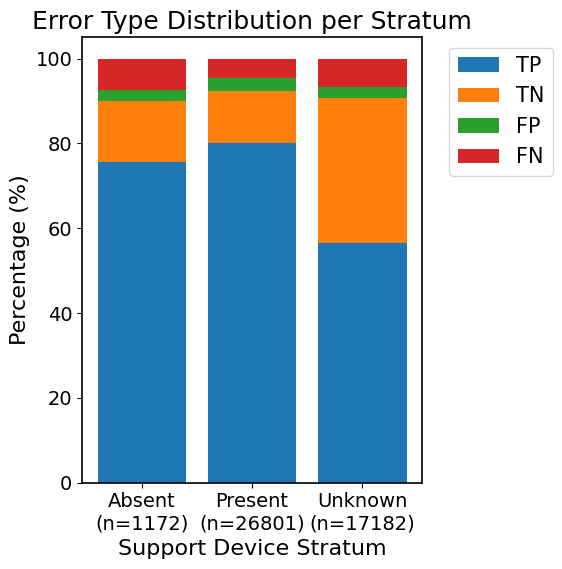

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Calculate counts and percentages in one pass
metrics = []
for stratum, subset in c2_df.groupby('stratum'):
    total = len(subset)
    tp = ((subset['true'] == 1) & (subset['pred'] == 1)).sum()
    tn = ((subset['true'] == 0) & (subset['pred'] == 0)).sum()
    fp = ((subset['true'] == 0) & (subset['pred'] == 1)).sum()
    fn = ((subset['true'] == 1) & (subset['pred'] == 0)).sum()
    
    metrics.append({
        'stratum': stratum,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'TP%': (tp/total)*100, 'TN%': (tn/total)*100, 
        'FP%': (fp/total)*100, 'FN%': (fn/total)*100
    })

results_df = pd.DataFrame(metrics).sort_values('stratum')

# 2. Print Summary
for _, row in results_df.iterrows():
    print(f"Stratum: {row['stratum']}")
    print(f"  TP: {row['TP']} ({row['TP%']:.2f}%), TN: {row['TN']} ({row['TN%']:.2f}%)")
    print(f"  FP: {row['FP']} ({row['FP%']:.2f}%), FN: {row['FN']} ({row['FN%']:.2f}%)")

# 3. Plotting
plt.figure(figsize=(6, 6))
strata = results_df['stratum']
categories = ['TP%', 'TN%', 'FP%', 'FN%']
bottom = np.zeros(len(strata))

for cat in categories:
    plt.bar(strata, results_df[cat], bottom=bottom, label=cat.replace('%', ''))
    bottom += results_df[cat]

plt.xlabel('Support Device Stratum')
plt.ylabel('Percentage (%)')
# Add strata size to tick labels
plt.xticks(ticks=range(len(strata)), labels=[f"{s}\n(n={results_df[results_df['stratum'] == s]['TP'].values[0] + results_df[results_df['stratum'] == s]['TN'].values[0] + results_df[results_df['stratum'] == s]['FP'].values[0] + results_df[results_df['stratum'] == s]['FN'].values[0]})" for s in strata])
plt.title('Error Type Distribution per Stratum')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [49]:
# Load all C2 predictions from the 5 separate fold files
FOLDS = [0, 1, 2, 3, 4]
fold_file = '/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/fold_{FOLD}_predictions.csv'

for fold in FOLDS:
    fold_df = pd.read_csv(fold_file.format(FOLD=fold))
    
fold_0 = pd.read_csv(fold_file.format(FOLD=0))
fold_0.head()    

,path,effusion_prob,effusion_true,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,MLP_B2_prob,MLP_B3_prob,MLP_B4_prob,MLP_B5_prob,MLP_M1_prob,MLP_M2_prob,MLP_M3_prob,MLP_M4_prob,MLP_M5_prob,MLP_M6_prob
0,CheXpert-v1.0-small/train/patient00008/study1/...,0.989891,1.0,-0.001258,-0.002981,0.004603,0.001782,0.038358,0.399419,-0.001282,...,0.911461,0.993021,0.937656,0.988203,0.990234,1.000000,1.000000,1.000000,1.000000,1.000000
1,CheXpert-v1.0-small/train/patient00008/study2/...,0.803473,1.0,-0.001191,-0.002815,0.002819,0.001348,0.057667,0.703849,-0.001344,...,0.931416,0.990229,0.932353,0.998319,0.980807,0.999987,0.991720,0.999688,0.999998,0.996500
2,CheXpert-v1.0-small/train/patient00010/study1/...,0.022443,0.0,-0.001185,-0.000544,0.002301,0.005169,-0.117937,-0.033050,-0.001290,...,0.977377,0.971201,0.970851,0.976558,0.732228,0.999998,0.999998,0.999905,1.000000,0.999991
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.061503,0.0,-0.001186,-0.001272,0.003885,0.003653,-0.103996,0.122837,-0.001299,...,0.923050,0.898308,0.916926,0.855302,0.945142,0.999998,0.999970,0.999894,1.000000,0.999952
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.029165,0.0,-0.001169,-0.001557,0.002562,0.004091,-0.134545,0.211838,-0.001316,...,0.947813,0.936584,0.955979,0.950232,0.921419,0.999195,0.999350,0.943226,1.000000,0.999999


In [ ]:
# Stratify the fold 0 predictions 
fold_0 = fold_0.merge(chex_df, left_on='path', right_on='Path', how='left')
fold_0['stratum'] = fold_0['Support Devices'].apply(label_stratum)
fold_0.head()

,path,effusion_prob,effusion_true,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,MLP_B5_prob,MLP_M1_prob,MLP_M2_prob,MLP_M3_prob,MLP_M4_prob,MLP_M5_prob,MLP_M6_prob,Path,Support Devices,stratum
0,CheXpert-v1.0-small/train/patient00008/study1/...,0.989891,1.0,-0.001258,-0.002981,0.004603,0.001782,0.038358,0.399419,-0.001282,...,0.988203,0.990234,1.000000,1.000000,1.000000,1.000000,1.000000,CheXpert-v1.0-small/train/patient00008/study1/...,1.0,Present
1,CheXpert-v1.0-small/train/patient00008/study2/...,0.803473,1.0,-0.001191,-0.002815,0.002819,0.001348,0.057667,0.703849,-0.001344,...,0.998319,0.980807,0.999987,0.991720,0.999688,0.999998,0.996500,CheXpert-v1.0-small/train/patient00008/study2/...,1.0,Present
2,CheXpert-v1.0-small/train/patient00010/study1/...,0.022443,0.0,-0.001185,-0.000544,0.002301,0.005169,-0.117937,-0.033050,-0.001290,...,0.976558,0.732228,0.999998,0.999998,0.999905,1.000000,0.999991,CheXpert-v1.0-small/train/patient00010/study1/...,NaN,Unknown
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.061503,0.0,-0.001186,-0.001272,0.003885,0.003653,-0.103996,0.122837,-0.001299,...,0.855302,0.945142,0.999998,0.999970,0.999894,1.000000,0.999952,CheXpert-v1.0-small/train/patient00012/study2/...,1.0,Present
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.029165,0.0,-0.001169,-0.001557,0.002562,0.004091,-0.134545,0.211838,-0.001316,...,0.950232,0.921419,0.999195,0.999350,0.943226,1.000000,0.999999,CheXpert-v1.0-small/train/patient00012/study1/...,1.0,Present


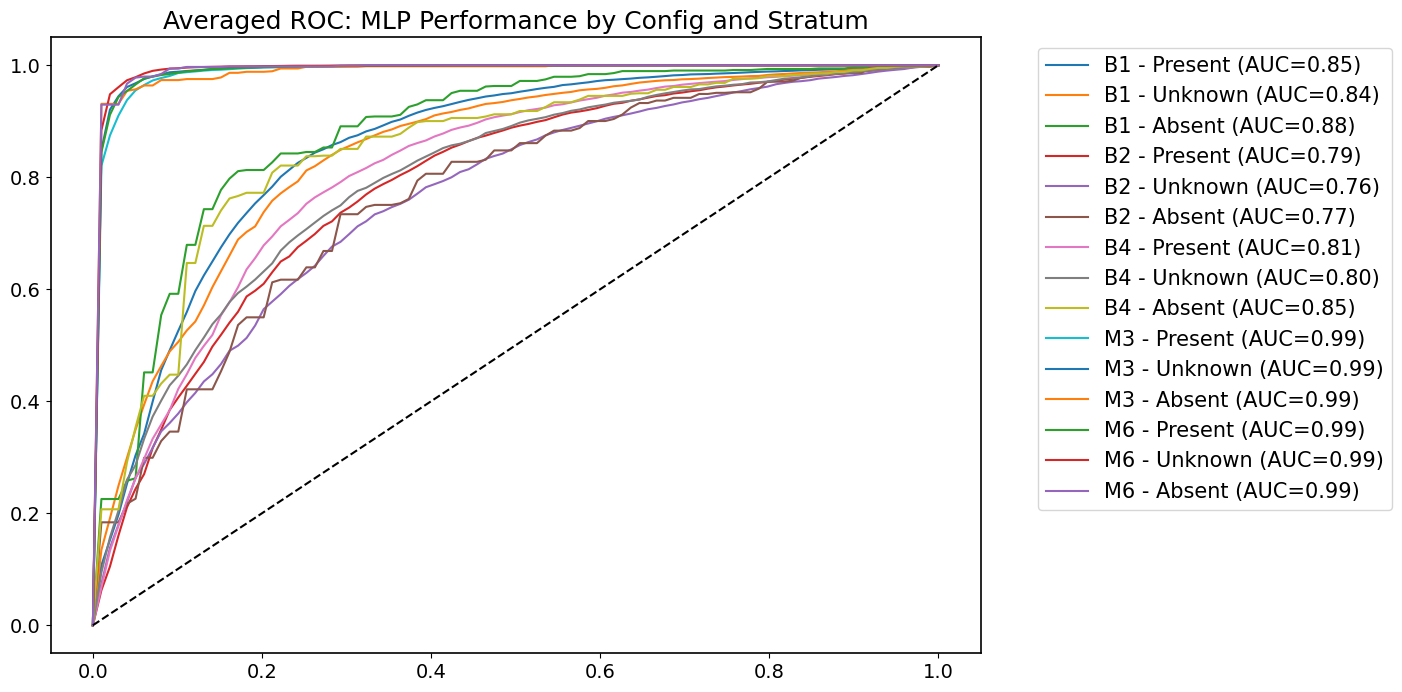

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

MODELS = ['MLP', 'LR', 'RF']
CONFIGS = ['B1', 'B2', 'B4', 'M3', 'M6']
mean_fpr = np.linspace(0, 1, 100)

# Dictionary to hold: {(model, config, stratum): [list of interp_tprs]}
results_master = {}

for fold in FOLDS:
    fold_df = pd.read_csv(fold_file.format(FOLD=fold))
    fold_df = fold_df.merge(chex_df, left_on='path', right_on='Path', how='left')
    fold_df['stratum'] = fold_df['Support Devices'].apply(label_stratum)
    
    unique_strata = fold_df['stratum'].unique()

    for model in MODELS:
        for config in CONFIGS:
            col_name = f"{model}_{config}_prob"
            
            # Ensure the column exists before processing
            if col_name not in fold_df.columns:
                continue
                
            for stratum in unique_strata:
                subset = fold_df[fold_df['stratum'] == stratum]
                if len(subset) > 0:
                    fpr, tpr, _ = roc_curve(subset['correct'], subset[col_name])
                    interp_tpr = np.interp(mean_fpr, fpr, tpr)
                    interp_tpr[0] = 0.0
                    
                    key = (model, config, stratum)
                    if key not in results_master:
                        results_master[key] = []
                    results_master[key].append(interp_tpr)

# Example: Plotting results for just the MLP model across all configs
plt.figure(figsize=(12, 8))
for (model, config, stratum), tpr_list in results_master.items():
    if model == 'MLP':  # Filtering for one model to keep plot readable
        mean_tpr = np.mean(tpr_list, axis=0)
        mean_auc = auc(mean_fpr, mean_tpr)
        plt.plot(mean_fpr, mean_tpr, label=f"{config} - {stratum} (AUC={mean_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Averaged ROC: MLP Performance by Config and Stratum")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

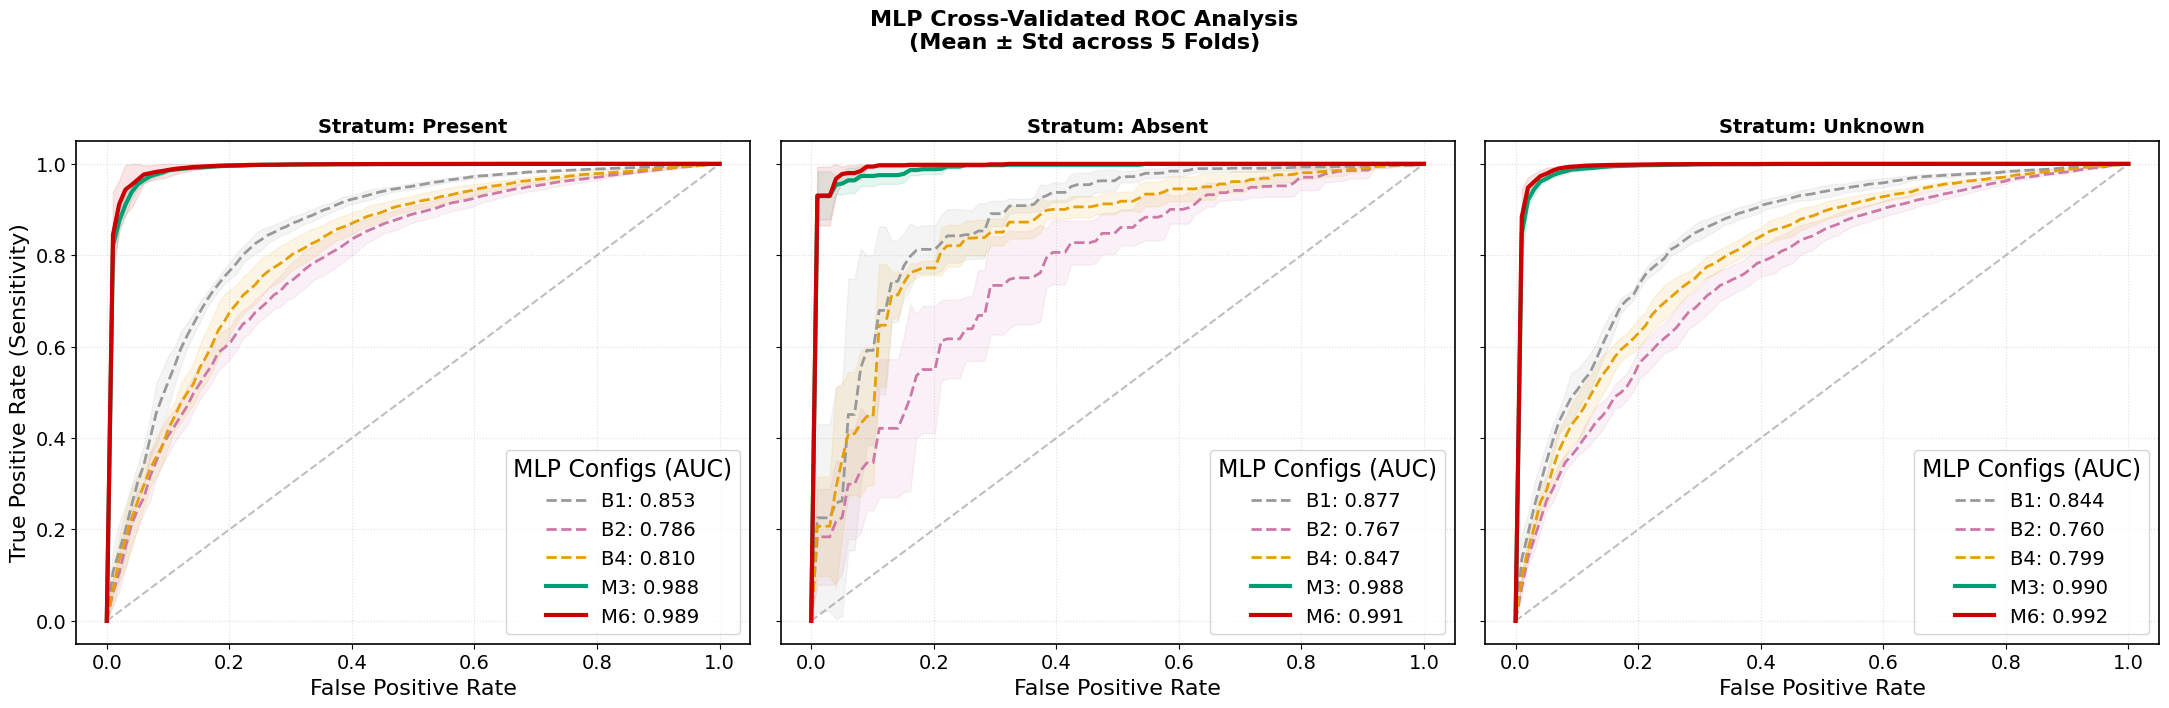

In [70]:
PLOT_COLORS = {
    'B1': '#999999',   # gray
    'B2': '#CC79A7',   # mauve/pink
    'B3': '#F0E442',   # yellow
    'B4': '#E69F00',   # amber
    'B5': '#D55E00',   # vermillion
    'M1': '#56B4E9',   # sky blue
    'M2': '#0072B2',   # deep blue
    'M3': '#009E73',   # teal-green
    'M4': '#9370DB',   # medium purple
    'M5': '#2D2D2D',   # black (full model)
    'M6': '#CC0000',   # red
}

PLOT_LS = {k: '--' if k.startswith('B') else '-' for k in PLOT_COLORS}
PLOT_LW = {k: 1.5  if k.startswith('B') else 2.2  for k in PLOT_COLORS}

# Which configs to show in ROC plots (per model), includes 3 baselines and 2 method
CONFIGS_TO_SHOW = {
    
    'MLP': ['B1', 'B2', 'B4', 'M3', 'M6'],
}

THRESHOLDS = np.arange(0.1, 1.0, 0.1)

# Plot styling
COLORS = {**PLOT_COLORS, 'M6': '#CC0000'}
LINESTYLES = {k: '--' if k.startswith('B') else '-' for k in COLORS} # Baselines dashed, models solid
LINEWIDTHS = {k: 2 if k.startswith('B') else 3 for k in COLORS} # Baselines thinner, models thicker
LABELS = { 
    'B1': 'B1 (Prob)',
    'B2': 'B2 (Attrs)',
    'B4': 'B4 (Prob + Attrs)',
    'M3': 'M3 (Prob+ΔA+Attrs)',
    'M6': 'M6 (Prob+ΔA+Attrs+CFProb)',
}

plt.rcParams.update({
    'font.size': 17,
    'axes.linewidth': 1.2,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
})
## ══════════════════════════════════════════════════════════════════════════════
# PLOTTING: STRATIFIED ROC CURVES (MLP ONLY) WITH INDIVIDUAL LEGENDS
# ══════════════════════════════════════════════════════════════════════════════

strata_to_plot = ['Present', 'Absent', 'Unknown'] 
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
mean_fpr = np.linspace(0, 1, 100)

for i, stratum in enumerate(strata_to_plot):
    ax = axes[i]
    # Chance line (hidden from legend for cleaner look)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5, label='_nolegend_')
    
    # Process MLP results
    for config in CONFIGS_TO_SHOW['MLP']:
        key = ('MLP', config, stratum)
        
        if key in results_master:
            tpr_list = results_master[key]
            
            # Statistics across folds
            mean_tpr = np.mean(tpr_list, axis=0)
            mean_tpr[-1] = 1.0
            std_tpr = np.std(tpr_list, axis=0)
            mean_auc = auc(mean_fpr, mean_tpr)
            
            # Styling from your config
            color = COLORS.get(config, '#333333')
            ls = LINESTYLES.get(config, '-')
            lw = LINEWIDTHS.get(config, 3)
            
            # Format label with specific AUC for this stratum
            label = f"{config}: {mean_auc:.3f}"
            
            ax.plot(mean_fpr, mean_tpr, color=color, linestyle=ls, linewidth=lw, label=label)
            ax.fill_between(mean_fpr, 
                            np.maximum(mean_tpr - std_tpr, 0), 
                            np.minimum(mean_tpr + std_tpr, 1), 
                            color=color, alpha=0.1)

    # Subplot Formatting
    ax.set_title(f"Stratum: {stratum}", fontsize=14, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    if i == 0:
        ax.set_ylabel('True Positive Rate (Sensitivity)')
    
    ax.grid(True, linestyle=':', alpha=0.4)
    
    # Place individual legend inside each plot
    ax.legend(loc='lower right', fontsize='small', title="MLP Configs (AUC)")

plt.suptitle(f"MLP Cross-Validated ROC Analysis\n(Mean ± Std across {len(FOLDS)} Folds)", 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()